In [1]:
#importing libraries
import pandas as pd 
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import r2_score,mean_absolute_error



In [2]:
#loading the dataset
df=pd.read_csv('Bengaluru_House_Data.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
#importing libraries
import pandas as pd

In [4]:
df=pd.read_csv('Bengaluru_House_Data.csv')
df.head

<bound method NDFrame.head of                   area_type   availability                  location  \
0      Super built-up  Area         19-Dec  Electronic City Phase II   
1                Plot  Area  Ready To Move          Chikka Tirupathi   
2            Built-up  Area  Ready To Move               Uttarahalli   
3      Super built-up  Area  Ready To Move        Lingadheeranahalli   
4      Super built-up  Area  Ready To Move                  Kothanur   
...                     ...            ...                       ...   
13315        Built-up  Area  Ready To Move                Whitefield   
13316  Super built-up  Area  Ready To Move             Richards Town   
13317        Built-up  Area  Ready To Move     Raja Rajeshwari Nagar   
13318  Super built-up  Area         18-Jun           Padmanabhanagar   
13319  Super built-up  Area  Ready To Move              Doddathoguru   

            size  society total_sqft  bath  balcony   price  
0          2 BHK  Coomee        1056   2.0 

In [5]:
df=df.drop(['area_type', 'balcony' ,'society' ,'availability'],axis=1)

In [6]:
df.head

<bound method NDFrame.head of                        location       size total_sqft  bath   price
0      Electronic City Phase II      2 BHK       1056   2.0   39.07
1              Chikka Tirupathi  4 Bedroom       2600   5.0  120.00
2                   Uttarahalli      3 BHK       1440   2.0   62.00
3            Lingadheeranahalli      3 BHK       1521   3.0   95.00
4                      Kothanur      2 BHK       1200   2.0   51.00
...                         ...        ...        ...   ...     ...
13315                Whitefield  5 Bedroom       3453   4.0  231.00
13316             Richards Town      4 BHK       3600   5.0  400.00
13317     Raja Rajeshwari Nagar      2 BHK       1141   2.0   60.00
13318           Padmanabhanagar      4 BHK       4689   4.0  488.00
13319              Doddathoguru      1 BHK        550   1.0   17.00

[13320 rows x 5 columns]>

In [7]:
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [8]:
#handling missing values
df["location"].value_counts() #count of houses in white field and sarjapur road are more.we can repace null 
df["location"] = df["location"].fillna("Sarjapur ROad")
df["location"].value_counts()

location
Whitefield                                      540
Sarjapur  Road                                  399
Electronic City                                 302
Kanakpura Road                                  273
Thanisandra                                     234
                                               ... 
Maragondana Halli, kr puram, old madras road      1
Chikkajala                                        1
Udayagiri                                         1
pavitra paradise                                  1
Chikbasavanapura                                  1
Name: count, Length: 1306, dtype: int64

In [9]:
df.isnull().sum()

location       0
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [10]:
#handling nan values in Bath column
med_bath = df["bath"].median()
med_bath
df["bath"] = df["bath"].fillna(med_bath)
#since mean value gave floating point number

In [11]:
df["bath"] = df["bath"].astype(int)
df["bath"].unique()

array([ 2,  5,  3,  4,  6,  1,  9,  8,  7, 11, 10, 14, 27, 12, 16, 40, 15,
       13, 18])

In [12]:
#drop duplicate rows
df.drop_duplicates(inplace=True)

In [13]:
df["location"].value_counts() #checking for outliers or inconsistent values or unrealistic data

location
Whitefield                   507
Sarjapur  Road               364
Electronic City              273
Thanisandra                  224
Kanakpura Road               223
                            ... 
Udayagiri                      1
pavitra paradise               1
kadubisnahalli                 1
Chuchangatta Colony            1
Electronic City Phase 1,       1
Name: count, Length: 1306, dtype: int64

In [14]:
#handling location column
df['location']=df["location"].apply(lambda x : x.strip())

In [15]:
loc = df['location'].value_counts()
loc_than_10 = loc[loc <= 10]
df['location'] = df['location'].apply(lambda x : 'others' if x in loc_than_10 else x)
df['location'].value_counts()

location
others                  2928
Whitefield               508
Sarjapur  Road           364
Electronic City          275
Thanisandra              226
                        ... 
Tindlu                    11
Banashankari Stage V      11
Doddakallasandra          11
Thyagaraja Nagar          11
HAL 2nd Stage             11
Name: count, Length: 232, dtype: int64

In [16]:
df['size'].value_counts()
# Fixed List Comprehension
out = [int(str(i).split()[0]) if pd.notnull(i) else 0 for i in df['size']]
df['bhk'] = out



In [17]:
def clean_sqft(sqft):
    if isinstance(sqft,str):
        sqft = sqft.strip()
        if '_' in  sqft:
            li = sqft.split('-')
            try:
                return (float(li[10]) + float(li[1]))/2
            except:
                return None
        try:
            return float(sqft)
        except:
            return None
    elif isinstance(sqft, (int,float)):
        return float(sqft)
    else:
        return None
df['total_sqft'] = df['total_sqft'].apply(clean_sqft)
df['total_sqft'] = df['total_sqft'].fillna(round(df["total_sqft"].mean()))


In [18]:
df['total_sqft'].value_counts()

total_sqft
1200.0     774
1572.0     246
1100.0     203
1500.0     201
2400.0     194
          ... 
7150.0       1
1557.0       1
1264.0       1
1701.0       1
30400.0      1
Name: count, Length: 1896, dtype: int64

In [19]:
#create price_per_sqft
#formula : price/total_sqft
df["price_per_sqft"] = df["price"]*100000/df["total_sqft"] #this will help us to find the outliers

In [20]:
#in total_sqft there are values like 1.000000 od sqft which is not normal , ie,
#total_sqft/hbk =>300 ,which will be realistic
# in total_sqft column we have some rooms with less than 300 sqft those are outliers
df = df[df['total_sqft']/df['bhk'] >= 300]

In [21]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,11705.000000,11705.000000,11705.000000,11705.000000,11705.000000
mean,1609.104683,2.579667,114.455648,2.664075,6433.552419
std,1286.606256,1.099383,156.421987,1.000305,4356.473098
min,300.000000,1.000000,8.440000,0.000000,267.829813
25%,1125.000000,2.000000,50.000000,2.000000,4232.164450
50%,1323.000000,2.000000,71.000000,3.000000,5350.289762
75%,1705.000000,3.000000,120.000000,3.000000,7028.571429
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


In [22]:
#handling outliers in bhk
df = df[df["bhk"] <= 6] # keeping only rhe bhk where the value is 6

In [23]:
#handling outliers in Bath column
#bhk + 2 - because we can have atleast
df = df[df["bath"] < df["bhk"] + 2]
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,others,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


<Axes: xlabel='price_per_sqft'>

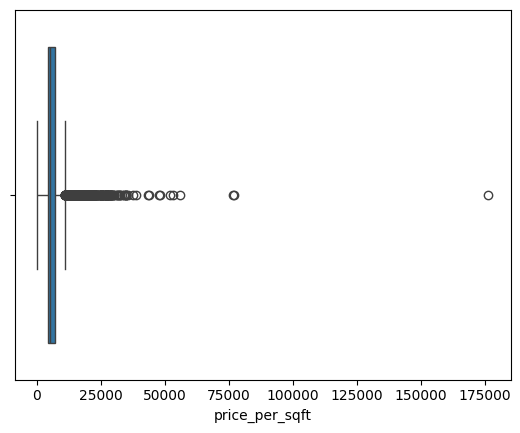

In [24]:
sns.boxplot(x="price_per_sqft",data = df)

<Axes: xlabel='price_per_sqft'>

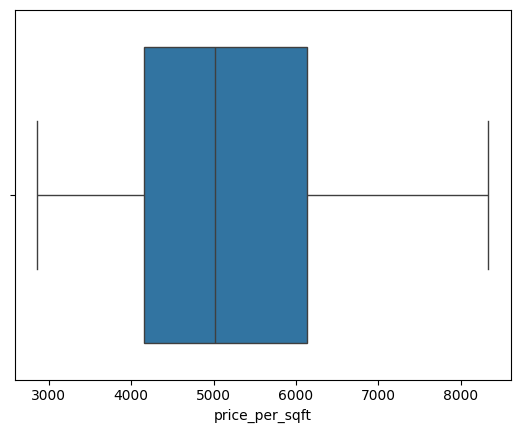

In [25]:
q1 = df['price_per_sqft'].quantile(0.25)
q3 = df['price_per_sqft'].quantile(0.75)

IQR = q3 - q1

lower = q1- 0.5 * IQR #we are using 0.5 because we want to be more strict in removing outliers
upper = q3 + 0.5* IQR

df = df[(df["price_per_sqft"]>= lower) & (df["price_per_sqft"] <= upper)]
sns.boxplot(x="price_per_sqft",data=df)


In [26]:
#after all the cleaning , our index value has been jumbled up
df.reset_index(drop=True,inplace=True)
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
9402,Rachenahalli,2 BHK,1050.0,2,52.71,2,5020.000000
9403,Bellandur,2 BHK,1262.0,2,47.00,2,3724.247227
9404,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
9405,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926


In [27]:
df = pd.get_dummies(df,columns=["location"],drop_first = True,dtype = int)

In [28]:
df.columns

Index(['size', 'total_sqft', 'bath', 'price', 'bhk', 'price_per_sqft',
       'location_1st Phase JP Nagar', 'location_2nd Stage Nagarbhavi',
       'location_5th Block Hbr Layout', 'location_5th Phase JP Nagar',
       ...
       'location_Vishveshwarya Layout', 'location_Vishwapriya Layout',
       'location_Vittasandra', 'location_Whitefield',
       'location_Yelachenahalli', 'location_Yelahanka',
       'location_Yelahanka New Town', 'location_Yelenahalli',
       'location_Yeshwanthpur', 'location_others'],
      dtype='object', length=236)

In [29]:
df = df.drop('size', axis = 1)

In [30]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

In [31]:
#divide into input and output
X = df.drop(["price","price_per_sqft"],axis =1)
y = df.price

In [32]:
#explit the datainto training and testing data
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [33]:
#model training using GridSearchCV to dynamically
model = RandomForestRegressor(random_state=42)
params = {
    "n_estimators":[100,150,200],
    "max_depth":[3,4,5,6,7]
}

grid = GridSearchCV(estimator=model,param_grid=params,cv=5)

grid.fit(Xtrain,ytrain)

print("Best params : ",grid.best_params_)
print("Best Score : ",grid.best_score_)

Best params :  {'max_depth': 7, 'n_estimators': 100}
Best Score :  0.8005800405732219


In [34]:
best_model = grid.best_estimator_
ypred = grid.predict(Xtest)
ypred
print("Training Eff: ",grid.score(Xtrain,ytrain))
print("Testing Eff: ",grid.score(Xtest,ytest))
print("R2: ",r2_score(ytest,ypred))
print("MAE: ",mean_absolute_error(ytest,ypred))

Training Eff:  0.8788691134258529
Testing Eff:  0.8266146637749054
R2:  0.8266146637749054
MAE:  14.315906192872145


In [35]:
df.to_csv("cleaned_df.csv")

In [36]:
joblib.dump(best_model,'rf_model.joblib')
joblib.dump(Xtrain.columns.tolist(),'model_columnn.joblib')

['model_columnn.joblib']